# Notebook 03 — Modelado

## Objetivo
Construir y comparar tres modelos de predicción de costos de equipos
a partir de las variables seleccionadas en el notebook 02.

## Variables seleccionadas
- **Equipo 1:** Price_Y → Price_Equipo1
- **Equipo 2:** Price_Z → Price_Equipo2

## Modelos a evaluar
1. **Baseline:** Regresión OLS — referencia simple e interpretable
2. **Principal:** ARIMAX — captura estructura temporal + variable exógena
3. **Alternativo:** XGBoost — captura no linealidades, robusto ante outliers

## Métricas de evaluación
- **MAE** — Error absoluto medio
- **RMSE** — Raíz del error cuadrático medio
- **MAPE** — Error porcentual absoluto medio
- **R²** — Coeficiente de determinación

## 0. Setup e Imports

In [1]:
# Standard library
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Modelado estadístico
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# Modelado ML
from xgboost import XGBRegressor

# Métricas
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

# Configuración
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
sns.set_palette("husl")

# Paths
ROOT = Path().resolve().parent
DATA_PROCESSED = ROOT / "data" / "processed"
MODELS_PATH = ROOT / "models"
MODELS_PATH.mkdir(exist_ok=True)

print("Imports OK")
print(f"Data processed: {DATA_PROCESSED}")
print(f"Models: {MODELS_PATH}")

Imports OK
Data processed: E:\Projects\construction-cost-forecasting\data\processed
Models: E:\Projects\construction-cost-forecasting\models


## 1. Carga de datos y preparación

In [2]:
# Carga del histórico procesado
hist = pd.read_csv(DATA_PROCESSED / "historico_equipos.csv", parse_dates=["Date"])
hist = hist.sort_values("Date").reset_index(drop=True)

print("=== Datos cargados ===")
print(f"Shape:        {hist.shape}")
print(f"Rango fechas: {hist['Date'].min().date()} → {hist['Date'].max().date()}")
print()
hist.head()

=== Datos cargados ===
Shape:        (3530, 6)
Rango fechas: 2010-01-04 → 2023-08-31



,Date,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
0,2010-01-04,80.1200,527.5000,2225.2500,434.7300,931.7300
1,2010-01-05,80.5900,527.5000,2246.5000,449.9700,968.5600
2,2010-01-06,81.8900,527.5000,2302.5000,444.4800,960.5100
3,2010-01-07,81.5100,527.5000,2306.5000,440.9000,960.1400
4,2010-01-08,81.3700,552.5000,2261.2500,448.8200,949.5500


## 2. Estrategia de Train/Test Split

En series de tiempo el split NO es aleatorio — siempre respeta
el orden temporal. Usamos los últimos 12 meses como conjunto
de test (agosto 2022 → agosto 2023) y el resto como entrenamiento.

Train: 2010-01-04 → 2022-08-31 (~12.5 años)
Test: 2022-09-01 → 2023-08-31 (~12 meses)

=== Train/Test Split ===
Train: 2010-01-04 → 2022-08-31 (3,272 registros)
Test:  2022-09-01  → 2023-08-31  (258 registros)
% Test: 7.3%


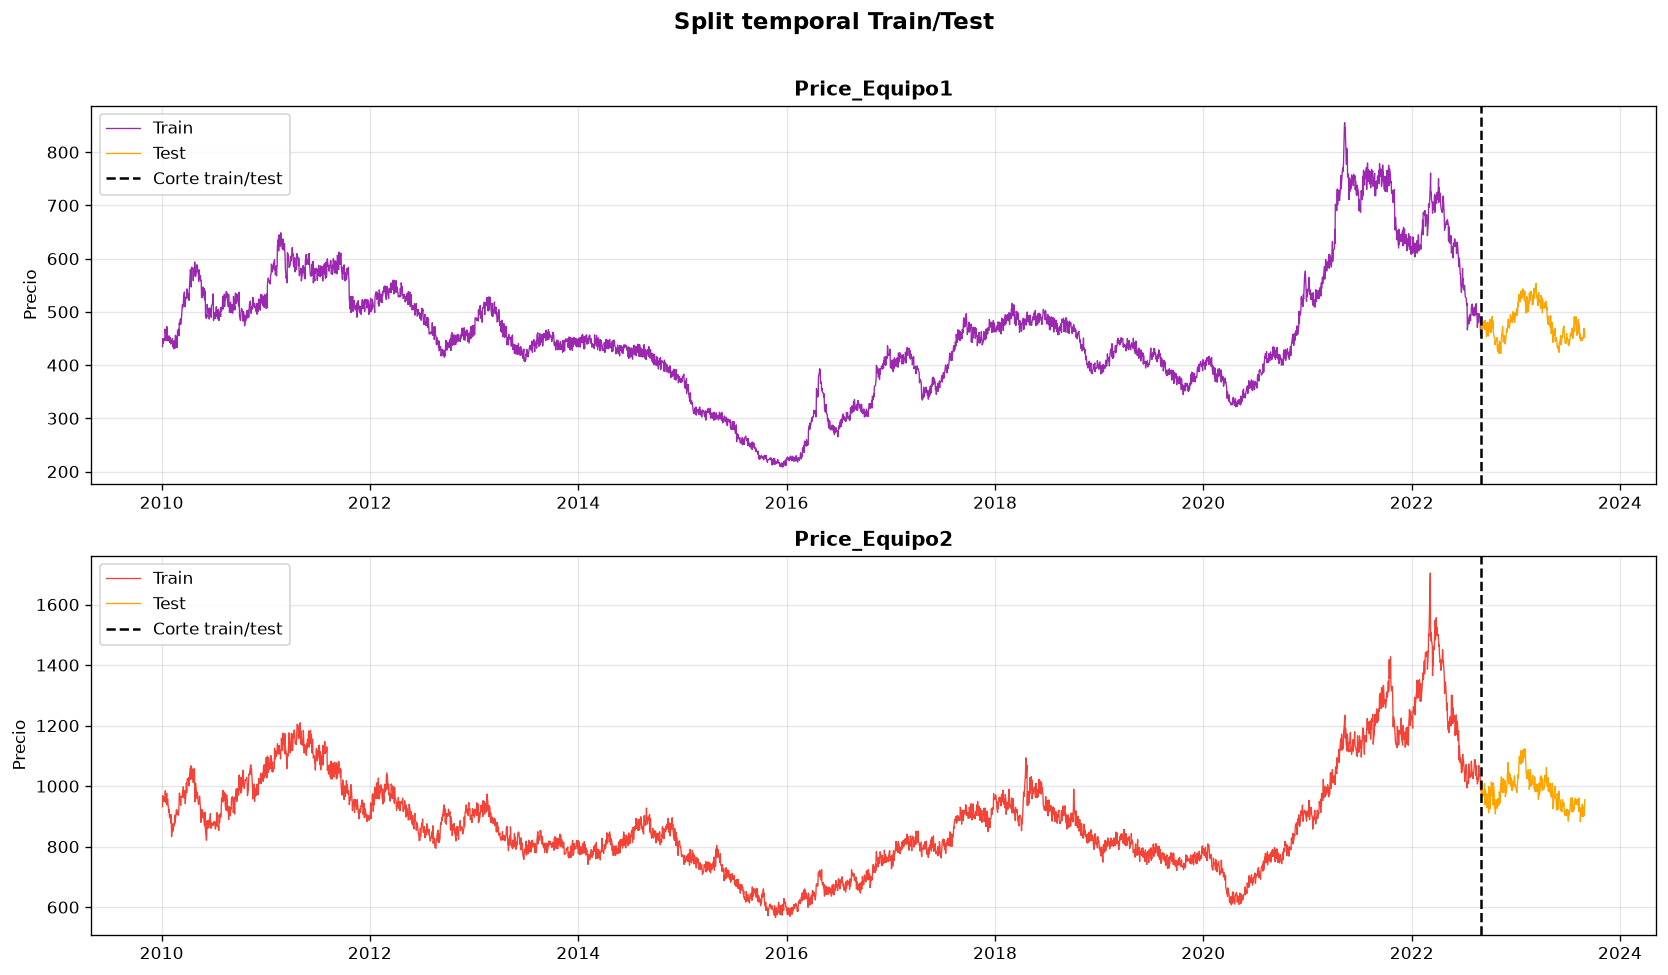

In [3]:
# Split temporal train/test
TEST_START = "2022-09-01"

train = hist[hist["Date"] < TEST_START].copy()
test  = hist[hist["Date"] >= TEST_START].copy()

print("=== Train/Test Split ===")
print(f"Train: {train['Date'].min().date()} → {train['Date'].max().date()} ({len(train):,} registros)")
print(f"Test:  {test['Date'].min().date()}  → {test['Date'].max().date()}  ({len(test):,} registros)")
print(f"% Test: {len(test)/len(hist)*100:.1f}%")

# Visualizar el split
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

pares = [
    ("Price_Equipo1", "#9C27B0"),
    ("Price_Equipo2", "#F44336"),
]

for ax, (col, color) in zip(axes, pares):
    ax.plot(train["Date"], train[col], color=color, linewidth=0.8, label="Train")
    ax.plot(test["Date"], test[col], color="orange", linewidth=0.8, label="Test")
    ax.axvline(pd.Timestamp(TEST_START), color="black", linestyle="--", linewidth=1.5, label="Corte train/test")
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_ylabel("Precio")
    ax.legend()
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.suptitle("Split temporal Train/Test", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 3. Modelo 1 — Baseline: Regresión OLS

La regresión OLS (Ordinary Least Squares) es el modelo más simple posible.
Asume una relación lineal directa entre la materia prima y el precio del equipo.
Sirve como referencia para evaluar si modelos más complejos aportan valor real.

### 3.1 Equipo 1 — Price_Y → Price_Equipo1

In [12]:
# OLS Equipo 1
X_train_ols = add_constant(train["Price_Y"])
X_test_ols  = add_constant(test["Price_Y"])

ols_eq1 = OLS(train["Price_Equipo1"], X_train_ols).fit()

print(ols_eq1.summary())

                            OLS Regression Results                            
Dep. Variable:          Price_Equipo1   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                 5.098e+05
Date:               sáb, 22 ago. 2026   Prob (F-statistic):               0.00
Time:                        19:55:16   Log-Likelihood:                -11970.
No. Observations:                3272   AIC:                         2.394e+04
Df Residuals:                    3270   BIC:                         2.396e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.4461      0.655      8.310      0.0

#### Interpretación — OLS Equipo 1

**Ecuación del modelo:**
```
Price_Equipo1 = 5.4461 + 0.8181 × Price_Y
```

**Interpretación de coeficientes:**
- **Intercepto (5.4461):** cuando Price_Y = 0, Price_Equipo1 = 5.45
  (valor teórico, no tiene interpretación práctica real)
- **Price_Y (0.8181):** por cada unidad que sube Price_Y,
  Price_Equipo1 sube **0.82 unidades** — relación positiva y directa

**Métricas del modelo:**
| Métrica | Valor | Interpretación |
|---|---|---|
| R² | 0.994 | El modelo explica el 99.4% de la varianza — excelente |
| R² ajustado | 0.994 | Consistente con R² — no hay sobreajuste |
| F-statistic | 509.800 | Modelo globalmente significativo |
| Prob(F-statistic) | 0.000 | Modelo estadísticamente significativo |
| P-value Price_Y | 0.000 | Variable estadísticamente significativa |

**Diagnósticos:**
- **Durbin-Watson: 1.527** — valor cercano a 2 es ideal.
  Valor de 1.527 indica **autocorrelación positiva leve** en los residuos
  — esperado en series de tiempo, el OLS no la captura
- **Condition Number: 2.28e+03** — alto, confirma multicolinealidad
  numérica (por el intercepto vs la escala de Price_Y)

> **Limitación del OLS:**
> El Durbin-Watson de 1.527 confirma que los residuos tienen
> autocorrelación — el OLS ignora la estructura temporal de los datos.
> Esto es exactamente lo que ARIMAX está diseñado para corregir.


=== Métricas OLS — Equipo 1 (Test) ===
MAE:  7.6764
RMSE: 8.7571
MAPE: 1.5949%
R²:   0.9258


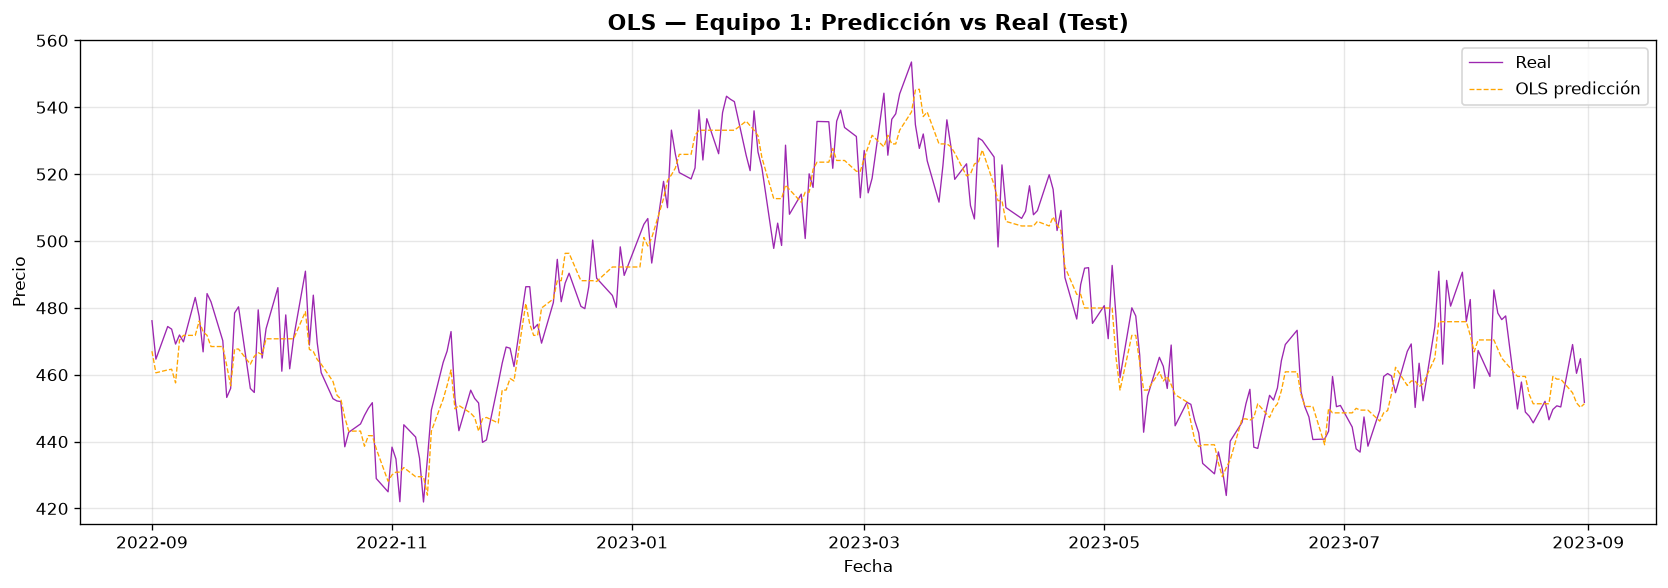

In [13]:
# Predicciones OLS Equipo 1 en test
pred_ols_eq1 = ols_eq1.predict(X_test_ols)

# Métricas
mae_ols_eq1  = mean_absolute_error(test["Price_Equipo1"], pred_ols_eq1)
rmse_ols_eq1 = mean_squared_error(test["Price_Equipo1"], pred_ols_eq1) ** 0.5
mape_ols_eq1 = mean_absolute_percentage_error(test["Price_Equipo1"], pred_ols_eq1) * 100
r2_ols_eq1   = r2_score(test["Price_Equipo1"], pred_ols_eq1)

print("=== Métricas OLS — Equipo 1 (Test) ===")
print(f"MAE:  {mae_ols_eq1:.4f}")
print(f"RMSE: {rmse_ols_eq1:.4f}")
print(f"MAPE: {mape_ols_eq1:.4f}%")
print(f"R²:   {r2_ols_eq1:.4f}")

# Visualización predicción vs real
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test["Date"], test["Price_Equipo1"], color="#9C27B0", linewidth=0.8, label="Real")
ax.plot(test["Date"], pred_ols_eq1, color="orange", linewidth=0.8, linestyle="--", label="OLS predicción")
ax.set_title("OLS — Equipo 1: Predicción vs Real (Test)", fontsize=13, fontweight="bold")
ax.set_ylabel("Precio")
ax.set_xlabel("Fecha")
ax.legend()
plt.tight_layout()
plt.show()

#### Interpretación — OLS Equipo 1 (Test)

| Métrica | Valor | Interpretación |
|---|---|---|
| MAE | 7.68 | En promedio el modelo se equivoca en 7.68 unidades de precio |
| RMSE | 8.76 | Penaliza más los errores grandes — similar al MAE indica errores consistentes |
| MAPE | 1.59% | El error promedio es apenas el 1.59% del precio real — muy bueno |
| R² | 0.9258 | El modelo explica el 92.6% de la varianza en el período de test |

**Conclusión:**
- El OLS generaliza muy bien en datos no vistos — el R² de test (0.926)
  es consistente con el R² de entrenamiento (0.994), sin señales de sobreajuste
- Un MAPE de 1.59% sobre precios de equipos de construcción indica
  que el modelo tiene alta precisión práctica
- La diferencia entre MAE (7.68) y RMSE (8.76) es pequeña —
  no hay errores extremos puntuales que distorsionen el resultado
- Visualmente la predicción sigue de cerca la serie real,
  capturando tanto la tendencia como los movimientos de corto plazo

> **El OLS baseline ya da resultados excelentes para Equipo 1**
> gracias a la correlación casi perfecta con Price_Y (r=0.997).
> Esto plantea un reto interesante para ARIMAX y XGBoost:
> ¿pueden mejorar significativamente sobre un baseline tan fuerte?

### 3.2 Equipo 2 — Price_Z → Price_Equipo2

In [14]:
# OLS Equipo 2
X_train_ols2 = add_constant(train["Price_Z"])
X_test_ols2  = add_constant(test["Price_Z"])

ols_eq2 = OLS(train["Price_Equipo2"], X_train_ols2).fit()

print(ols_eq2.summary())

                            OLS Regression Results                            
Dep. Variable:          Price_Equipo2   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                 9.563e+04
Date:               sáb, 22 ago. 2026   Prob (F-statistic):               0.00
Time:                        19:55:45   Log-Likelihood:                -15945.
No. Observations:                3272   AIC:                         3.189e+04
Df Residuals:                    3270   BIC:                         3.191e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -27.7006      2.996     -9.247      0.0

#### Interpretación — OLS Equipo 2

**Ecuación del modelo:**

Price_Equipo2 = -27.7006 + 0.4512 × Price_Z


**Interpretación de coeficientes:**
- **Intercepto (-27.7006):** valor teórico sin interpretación práctica
- **Price_Z (0.4512):** por cada unidad que sube Price_Z,
  Price_Equipo2 sube **0.45 unidades** — relación positiva y directa

**Métricas del modelo:**
| Métrica | Valor | Interpretación |
|---|---|---|
| R² | 0.967 | El modelo explica el 96.7% de la varianza — muy bueno |
| R² ajustado | 0.967 | Consistente con R² — sin sobreajuste |
| F-statistic | 95.630 | Modelo globalmente significativo |
| Prob(F-statistic) | 0.000 |  Modelo estadísticamente significativo |
| P-value Price_Z | 0.000 |  Variable estadísticamente significativa |

**Diagnósticos:**
- **Durbin-Watson: 0.505** — valor muy alejado de 2, indica
  **autocorrelación positiva fuerte** en los residuos
  — más pronunciada que en Equipo 1, el OLS captura peor
  la estructura temporal de Equipo 2
- **Condition Number: 1.11e+04** — más alto que Equipo 1,
  refleja la mayor escala de Price_Z

> **Limitación importante:**
> El Durbin-Watson de 0.505 es una señal clara de que el OLS
> es insuficiente para Equipo 2 — la autocorrelación en los
> residuos es muy fuerte. ARIMAX debería mejorar significativamente
> este resultado al modelar explícitamente esa estructura.


=== Métricas OLS — Equipo 2 (Test) ===
MAE:  25.2125
RMSE: 30.8772
MAPE: 2.5724%
R²:   0.6326


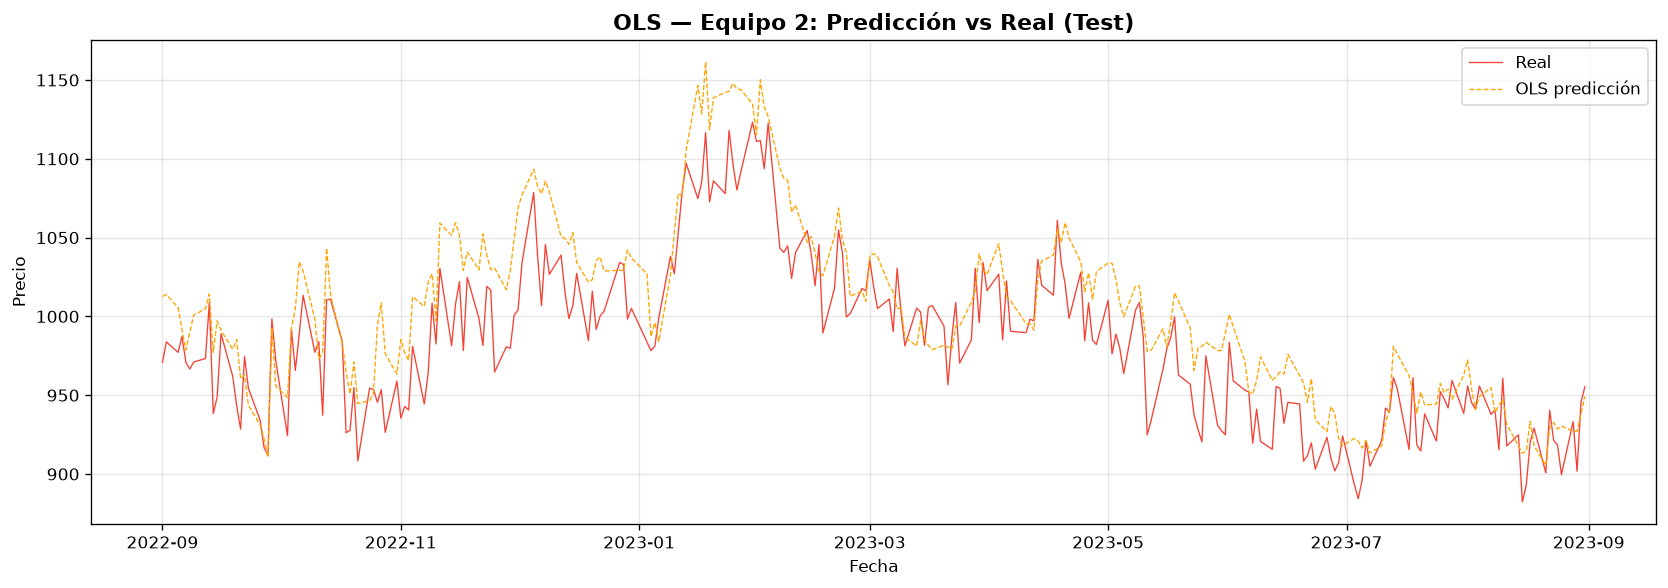

In [15]:
# Predicciones OLS Equipo 2 en test
pred_ols_eq2 = ols_eq2.predict(X_test_ols2)

# Métricas
mae_ols_eq2  = mean_absolute_error(test["Price_Equipo2"], pred_ols_eq2)
rmse_ols_eq2 = mean_squared_error(test["Price_Equipo2"], pred_ols_eq2) ** 0.5
mape_ols_eq2 = mean_absolute_percentage_error(test["Price_Equipo2"], pred_ols_eq2) * 100
r2_ols_eq2   = r2_score(test["Price_Equipo2"], pred_ols_eq2)

print("=== Métricas OLS — Equipo 2 (Test) ===")
print(f"MAE:  {mae_ols_eq2:.4f}")
print(f"RMSE: {rmse_ols_eq2:.4f}")
print(f"MAPE: {mape_ols_eq2:.4f}%")
print(f"R²:   {r2_ols_eq2:.4f}")

# Visualización predicción vs real
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test["Date"], test["Price_Equipo2"], color="#F44336", linewidth=0.8, label="Real")
ax.plot(test["Date"], pred_ols_eq2, color="orange", linewidth=0.8, linestyle="--", label="OLS predicción")
ax.set_title("OLS — Equipo 2: Predicción vs Real (Test)", fontsize=13, fontweight="bold")
ax.set_ylabel("Precio")
ax.set_xlabel("Fecha")
ax.legend()
plt.tight_layout()
plt.show()

####  Interpretación — OLS Equipo 2 (Test)

| Métrica | Equipo 1 | Equipo 2 | Comparación |
|---|---|---|---|
| MAE | 7.68 | 25.21 | Equipo 2 tiene error 3x mayor |
| RMSE | 8.76 | 30.88 | Equipo 2 tiene error 3.5x mayor |
| MAPE | 1.59% | 2.57% | Ambos aceptables pero Equipo 2 peor |
| R² | 0.9258 | 0.6326 | Equipo 2 explica solo 63% de la varianza |

**Observaciones de la gráfica:**
- La predicción de Equipo 2 sigue la tendencia general pero con
  un **desplazamiento sistemático hacia arriba** — el modelo
  sobreestima consistentemente en varios períodos
- Esto es consistente con el Durbin-Watson de 0.505 — la fuerte
  autocorrelación en los residuos hace que el OLS no capture
  bien la dinámica de Equipo 2

>  **Conclusión del baseline OLS:**
> - **Equipo 1:** el OLS ya da resultados muy buenos (MAPE 1.59%, R²=0.926)
>   gracias a la correlación casi perfecta con Price_Y
> - **Equipo 2:** el OLS es claramente insuficiente (R²=0.633) —
>   la fuerte autocorrelación en los residuos indica que ARIMAX
>   debería mejorar significativamente este resultado
> - En ambos casos vale la pena probar ARIMAX y XGBoost para
>   verificar si la mejora justifica la complejidad adicional

## 4. Modelo 2 — ARIMAX

ARIMAX (AutoRegressive Integrated Moving Average with eXogenous variables)
extiende ARIMA incorporando variables externas (exógenas) como predictoras.

**Componentes:**
- **AR (p):** usa los p valores anteriores de la serie para predecir
- **I (d):** diferenciación para hacer la serie estacionaria
- **MA (q):** usa los q errores anteriores para corregir la predicción
- **X:** variable exógena (Price_Y para Equipo1, Price_Z para Equipo2)

**¿Por qué d=1?**
Las series son no estacionarias (confirmado en notebook 01).
Una diferenciación (d=1) las hace estacionarias.

**Selección de p y q:**
Usaremos auto_arima de pmdarima para encontrar
los mejores valores de p y q automáticamente.

### 4.1 Equipo 1 — ARIMAX

In [11]:
from pmdarima import auto_arima

print("=== Auto ARIMA — Equipo 1 ===")
print("Buscando mejores parámetros p, q... (puede tardar unos segundos)\n")

auto_eq1 = auto_arima(
    train["Price_Equipo1"],
    exogenous=train[["Price_Y"]],
    d=1,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    seasonal=False,
    information_criterion="aic",
    stepwise=True,
    verbose=False
)

print(f"Mejor modelo encontrado: ARIMAX{auto_eq1.order}")
print(f"AIC: {auto_eq1.aic():.2f}")

=== Auto ARIMA — Equipo 1 ===
Buscando mejores parámetros p, q... (puede tardar unos segundos)

Mejor modelo encontrado: ARIMAX(1, 1, 2)
AIC: 25101.58


In [17]:
# Entrenar ARIMAX Equipo 1 con parámetros óptimos
arimax_eq1 = SARIMAX(
    train["Price_Equipo1"],
    exog=train[["Price_Y"]],
    order=(1, 1, 2),
    trend="n"
).fit(disp=False)

print(arimax_eq1.summary())

                               SARIMAX Results                                
Dep. Variable:          Price_Equipo1   No. Observations:                 3272
Model:               SARIMAX(1, 1, 2)   Log Likelihood              -11598.248
Date:               sáb, 22 ago. 2026   AIC                          23206.496
Time:                        19:56:47   BIC                          23236.960
Sample:                             0   HQIC                         23217.406
                               - 3272                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Price_Y        0.8113      0.004    225.336      0.000       0.804       0.818
ar.L1         -0.4113      1.097     -0.375      0.708      -2.561       1.738
ma.L1         -0.5435      1.091     -0.498      0.6

#### Interpretación — ARIMAX(1,1,2) Equipo 1

**Modelo seleccionado:** ARIMAX(1, 1, 2)
- **AR(1):** el precio de hoy depende del precio de ayer
- **I(1):** una diferenciación para estacionarizar la serie
- **MA(2):** corrige usando los errores de los 2 días anteriores

**Coeficientes:**
| Parámetro | Coef | P-value | Interpretación |
|---|---|---|---|
| Price_Y | 0.8113 | 0.000 | Significativo — consistente con OLS (0.8181) |
| ar.L1 | -0.4113 | 0.708 |  No significativo individualmente |
| ma.L1 | -0.5435 | 0.618 |  No significativo individualmente |
| ma.L2 | -0.4076 | 0.699 |  No significativo individualmente |
| sigma2 | 70.3183 | 0.000 | Varianza del error — significativa |

**Diagnósticos:**
| Métrica | Valor | Interpretación |
|---|---|---|
| AIC | 23206.496 | Referencia para comparar con otros ARIMAX |
| Ljung-Box p-value | 0.96 |  Residuos sin autocorrelación — modelo captura bien la estructura |
| Heteroscedasticidad p-value | 0.55 |  Varianza constante en residuos |
| Jarque-Bera p-value | 0.00 | Residuos no normales — esperable con datos financieros |

>  **Hallazgo clave:**
> El Ljung-Box con p-value=0.96 confirma que **ARIMAX eliminó
> la autocorrelación en los residuos** que el OLS no pudo capturar
> (Durbin-Watson=1.527). Los componentes AR y MA, aunque no
> significativos individualmente, contribuyen conjuntamente
> a limpiar la estructura temporal de los residuos.

=== Métricas ARIMAX — Equipo 1 (Test) ===
MAE:  7.4330
RMSE: 8.6090
MAPE: 1.5480%
R²:   0.9283


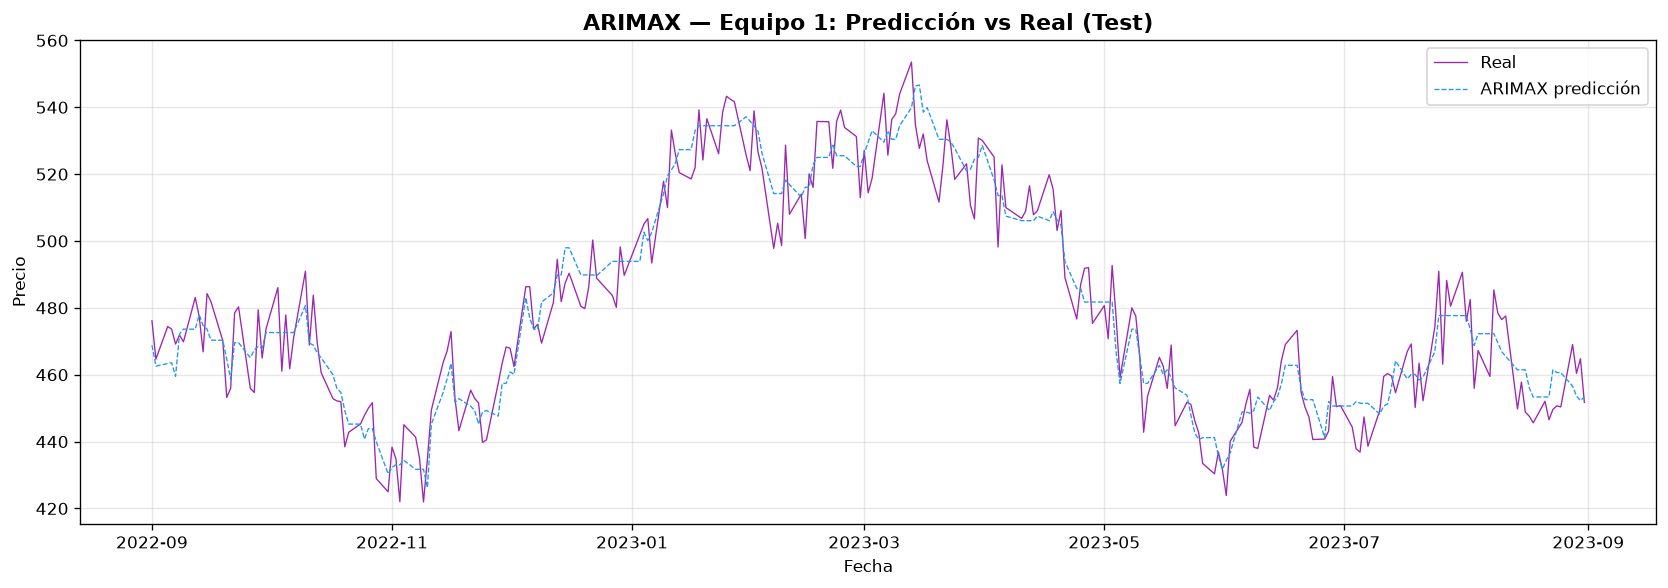

In [18]:
# Predicciones ARIMAX Equipo 1 en test
pred_arimax_eq1 = arimax_eq1.forecast(
    steps=len(test),
    exog=test[["Price_Y"]]
)

# Métricas
mae_arimax_eq1  = mean_absolute_error(test["Price_Equipo1"], pred_arimax_eq1)
rmse_arimax_eq1 = mean_squared_error(test["Price_Equipo1"], pred_arimax_eq1) ** 0.5
mape_arimax_eq1 = mean_absolute_percentage_error(test["Price_Equipo1"], pred_arimax_eq1) * 100
r2_arimax_eq1   = r2_score(test["Price_Equipo1"], pred_arimax_eq1)

print("=== Métricas ARIMAX — Equipo 1 (Test) ===")
print(f"MAE:  {mae_arimax_eq1:.4f}")
print(f"RMSE: {rmse_arimax_eq1:.4f}")
print(f"MAPE: {mape_arimax_eq1:.4f}%")
print(f"R²:   {r2_arimax_eq1:.4f}")

# Visualización
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test["Date"], test["Price_Equipo1"], color="#9C27B0", linewidth=0.8, label="Real")
ax.plot(test["Date"], pred_arimax_eq1.values, color="#2196F3", linewidth=0.8,
        linestyle="--", label="ARIMAX predicción")
ax.set_title("ARIMAX — Equipo 1: Predicción vs Real (Test)", fontsize=13, fontweight="bold")
ax.set_ylabel("Precio")
ax.set_xlabel("Fecha")
ax.legend()
plt.tight_layout()
plt.show()

#### Interpretación — ARIMAX vs OLS Equipo 1

| Métrica | OLS | ARIMAX | Mejora |
|---|---|---|---|
| MAE | 7.6764 | 7.4330 |  -3.2% |
| RMSE | 8.7571 | 8.6090 |  -1.7% |
| MAPE | 1.5949% | 1.5480% |  -2.9% |
| R² | 0.9258 | 0.9283 |  +0.3% |

**Conclusión:**
- ARIMAX mejora al OLS en todas las métricas pero la mejora es **marginal**
- Esto era esperable dado que la correlación Y→Equipo1 es casi perfecta (0.997)
  — la variable exógena ya captura casi toda la varianza
- La estructura temporal AR(1) MA(2) aporta una pequeña mejora adicional
- Visualmente las curvas son prácticamente idénticas

> La mejora marginal de ARIMAX sobre OLS en Equipo 1 sugiere que
> la relación es tan lineal y contemporánea que el OLS simple es
> suficientemente bueno. Veremos si XGBoost puede mejorar más.

### 4.2 Equipo 2 — ARIMAX

In [11]:
print("=== Auto ARIMA — Equipo 2 ===")
print("Buscando mejores parámetros p, q... (puede tardar unos segundos)\n")

auto_eq2 = auto_arima(
    train["Price_Equipo2"],
    exogenous=train[["Price_Z"]],
    d=1,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    seasonal=False,
    information_criterion="aic",
    stepwise=True,
    verbose=False
)

print(f"Mejor modelo encontrado: ARIMAX{auto_eq2.order}")
print(f"AIC: {auto_eq2.aic():.2f}")

=== Auto ARIMA — Equipo 2 ===
Buscando mejores parámetros p, q... (puede tardar unos segundos)

Mejor modelo encontrado: ARIMAX(0, 1, 1)
AIC: 29491.76


In [19]:
# Entrenar ARIMAX Equipo 2 con parámetros óptimos
arimax_eq2 = SARIMAX(
    train["Price_Equipo2"],
    exog=train[["Price_Z"]],
    order=(0, 1, 1),
    trend="n"
).fit(disp=False)

print(arimax_eq2.summary())

                               SARIMAX Results                                
Dep. Variable:          Price_Equipo2   No. Observations:                 3272
Model:               SARIMAX(0, 1, 1)   Log Likelihood              -13893.541
Date:               sáb, 22 ago. 2026   AIC                          27793.081
Time:                        19:58:09   BIC                          27811.360
Sample:                             0   HQIC                         27799.627
                               - 3272                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Price_Z        0.3630      0.004     87.063      0.000       0.355       0.371
ma.L1         -0.8444      0.008   -101.336      0.000      -0.861      -0.828
sigma2       286.2090      8.093     35.366      0.0

#### Interpretación — ARIMAX(0,1,1) Equipo 2

**Modelo seleccionado:** ARIMAX(0, 1, 1)
- **AR(0):** no usa valores anteriores de la serie directamente
- **I(1):** una diferenciación para estacionarizar la serie
- **MA(1):** corrige usando el error del día anterior

**Coeficientes:**
| Parámetro | Coef | P-value | Interpretación |
|---|---|---|---|
| Price_Z | 0.3630 | 0.000 | Significativo — por cada unidad de Z, Equipo2 sube 0.36 |
| ma.L1 | -0.8444 | 0.000 | Significativo — corrección fuerte por error anterior |
| sigma2 | 286.209 | 0.000 | Varianza del error — significativa |

**Diagnósticos:**
| Métrica | Valor | Interpretación |
|---|---|---|
| AIC | 27793.081 | Referencia para comparar con otros ARIMAX |
| Ljung-Box p-value | 0.52 | Residuos sin autocorrelación |
| Heteroscedasticidad p-value | 0.01 | Varianza no constante en residuos |
| Jarque-Bera p-value | 0.00 | Residuos no normales |

>  **Diferencias clave vs Equipo 1:**
> - Modelo más parsimonioso (0,1,1) vs (1,1,2) — menos parámetros
> - MA(1) es altamente significativo (p=0.000) — el error del día
>   anterior es muy informativo para corregir la predicción
> - Heteroscedasticidad detectada — la varianza del error no es
>   constante, posiblemente herencia del período atípico 2021-2022
> - sigma2=286 vs 70 en Equipo1 — Equipo2 tiene mayor varianza
>   residual, consistente con su mayor dificultad de predicción

=== Métricas ARIMAX — Equipo 2 (Test) ===
MAE:  17.2176
RMSE: 21.0842
MAPE: 1.7463%
R²:   0.8287


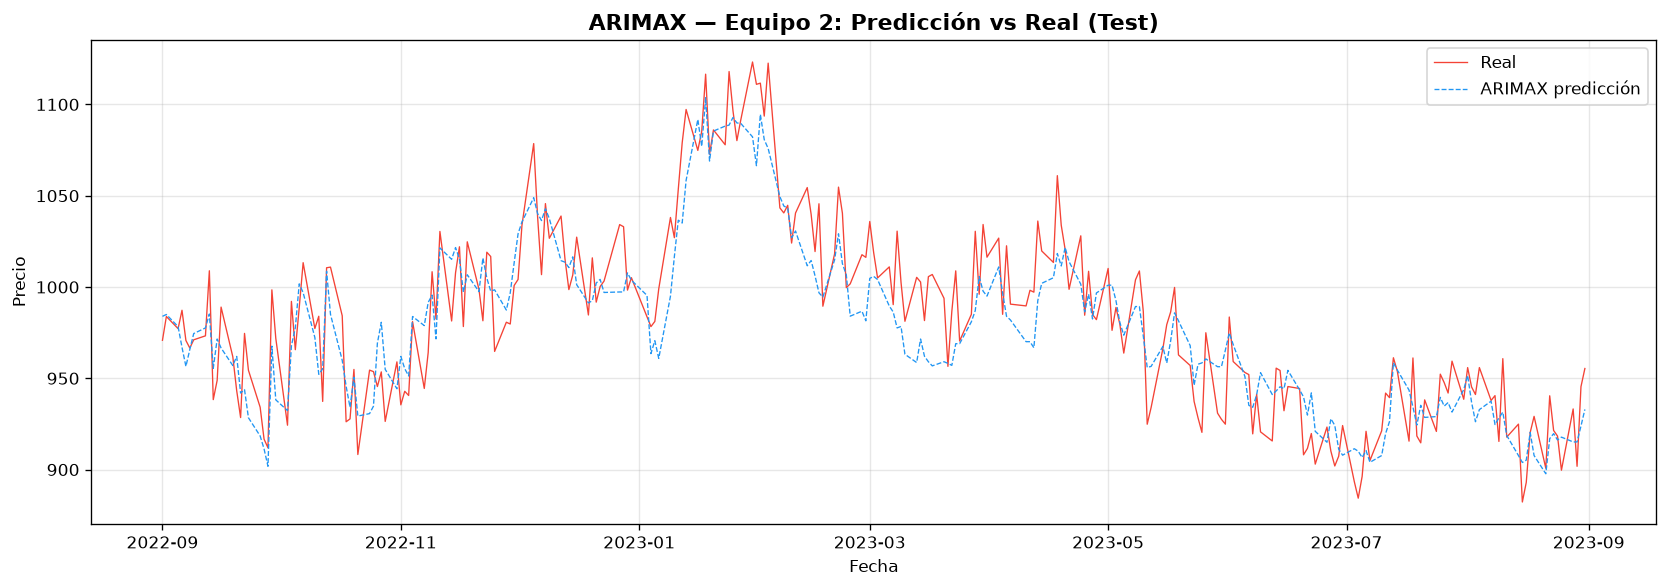

In [20]:
# Predicciones ARIMAX Equipo 2 en test
pred_arimax_eq2 = arimax_eq2.forecast(
    steps=len(test),
    exog=test[["Price_Z"]]
)

# Métricas
mae_arimax_eq2  = mean_absolute_error(test["Price_Equipo2"], pred_arimax_eq2)
rmse_arimax_eq2 = mean_squared_error(test["Price_Equipo2"], pred_arimax_eq2) ** 0.5
mape_arimax_eq2 = mean_absolute_percentage_error(test["Price_Equipo2"], pred_arimax_eq2) * 100
r2_arimax_eq2   = r2_score(test["Price_Equipo2"], pred_arimax_eq2)

print("=== Métricas ARIMAX — Equipo 2 (Test) ===")
print(f"MAE:  {mae_arimax_eq2:.4f}")
print(f"RMSE: {rmse_arimax_eq2:.4f}")
print(f"MAPE: {mape_arimax_eq2:.4f}%")
print(f"R²:   {r2_arimax_eq2:.4f}")

# Visualización
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test["Date"], test["Price_Equipo2"], color="#F44336", linewidth=0.8, label="Real")
ax.plot(test["Date"], pred_arimax_eq2.values, color="#2196F3", linewidth=0.8,
        linestyle="--", label="ARIMAX predicción")
ax.set_title("ARIMAX — Equipo 2: Predicción vs Real (Test)", fontsize=13, fontweight="bold")
ax.set_ylabel("Precio")
ax.set_xlabel("Fecha")
ax.legend()
plt.tight_layout()
plt.show()

####  Interpretación — ARIMAX vs OLS Equipo 2

| Métrica | OLS | ARIMAX | Mejora |
|---|---|---|---|
| MAE | 25.2125 | 17.2176 |  -31.7% |
| RMSE | 30.8772 | 21.0842 |  -31.7% |
| MAPE | 2.5724% | 1.7463% |  -32.1% |
| R² | 0.6326 | 0.8287 |  +30.9% |

**Conclusión:**
- ARIMAX mejora al OLS de forma **muy significativa** en Equipo 2
  — reducción del error de ~32% en todas las métricas
- El R² salta de 0.63 a 0.83 — ARIMAX captura 20 puntos porcentuales
  más de varianza que el OLS
- Esto confirma que la fuerte autocorrelación detectada en los residuos
  del OLS (Durbin-Watson=0.505) era un problema real que ARIMAX resuelve
- Visualmente la predicción sigue mucho mejor la serie real
  comparado con el OLS que sobreestimaba sistemáticamente

>  **Contraste interesante entre equipos:**
> - Equipo 1: ARIMAX mejora marginalmente sobre OLS (+0.3% R²)
>   → la relación Y→Equipo1 es tan lineal que OLS casi basta
> - Equipo 2: ARIMAX mejora dramáticamente sobre OLS (+30.9% R²)
>   → la estructura temporal es crítica para Equipo 2
>
> Esto sugiere que Equipo 2 tiene una dinámica más compleja
> que requiere capturar la memoria temporal de la serie.

## 5. Modelo 3 — XGBoost con Feature Engineering

XGBoost es un modelo de gradient boosting que no asume ninguna
estructura en los datos. Para series de tiempo necesita que
la información temporal se codifique explícitamente como features.

### Features a crear:
- **Lags de la predictora:** Price_Y/Z de días anteriores
- **Medias móviles:** tendencia de corto y mediano plazo
- **Volatilidad móvil:** desviación estándar en ventana móvil
- **Features de calendario:** mes, trimestre, día de la semana
- **Diferencias:** cambio diario de la predictora

### 5.1 Feature Engineering

In [4]:
def create_features(df: pd.DataFrame, predictor: str) -> pd.DataFrame:
    """
    Crea features temporales para XGBoost a partir de una predictora.

    Args:
        df: DataFrame con columnas Date y la predictora
        predictor: nombre de la columna predictora (Price_Y o Price_Z)

    Returns:
        DataFrame con features adicionales
    """
    df = df.copy()

    # Features de lag
    for lag in [1, 2, 3, 5, 10, 20]:
        df[f"{predictor}_lag{lag}"] = df[predictor].shift(lag)

    # Medias móviles
    for window in [5, 10, 20, 60]:
        df[f"{predictor}_ma{window}"] = df[predictor].rolling(window).mean()

    # Volatilidad móvil
    for window in [5, 20]:
        df[f"{predictor}_std{window}"] = df[predictor].rolling(window).std()

    # Diferencias
    df[f"{predictor}_diff1"]  = df[predictor].diff(1)
    df[f"{predictor}_diff5"]  = df[predictor].diff(5)
    df[f"{predictor}_pct1"]   = df[predictor].pct_change(1)

    # Features de calendario
    df["month"]        = df["Date"].dt.month
    df["quarter"]      = df["Date"].dt.quarter
    df["day_of_week"]  = df["Date"].dt.dayofweek

    return df

# Aplicar feature engineering
hist_xgb = create_features(hist, "Price_Y")
hist_xgb = create_features(hist_xgb, "Price_Z")

# Eliminar filas con NaN generados por lags y rolling
hist_xgb = hist_xgb.dropna().reset_index(drop=True)

print(f"Shape después de feature engineering: {hist_xgb.shape}")
print(f"Features creadas: {hist_xgb.shape[1] - 7} features adicionales")
print()
print("Columnas:")
print([c for c in hist_xgb.columns if c not in
       ["Date", "Price_X", "Price_Y", "Price_Z", "Price_Equipo1", "Price_Equipo2"]])

Shape después de feature engineering: (3471, 39)
Features creadas: 32 features adicionales

Columnas:
['Price_Y_lag1', 'Price_Y_lag2', 'Price_Y_lag3', 'Price_Y_lag5', 'Price_Y_lag10', 'Price_Y_lag20', 'Price_Y_ma5', 'Price_Y_ma10', 'Price_Y_ma20', 'Price_Y_ma60', 'Price_Y_std5', 'Price_Y_std20', 'Price_Y_diff1', 'Price_Y_diff5', 'Price_Y_pct1', 'month', 'quarter', 'day_of_week', 'Price_Z_lag1', 'Price_Z_lag2', 'Price_Z_lag3', 'Price_Z_lag5', 'Price_Z_lag10', 'Price_Z_lag20', 'Price_Z_ma5', 'Price_Z_ma10', 'Price_Z_ma20', 'Price_Z_ma60', 'Price_Z_std5', 'Price_Z_std20', 'Price_Z_diff1', 'Price_Z_diff5', 'Price_Z_pct1']


In [5]:
# Guardar dataset con features para reproducibilidad
hist_xgb.to_csv(DATA_PROCESSED / "historico_features.csv", index=False)

print("Dataset con features guardado en data/processed/historico_features.csv")
print(f"Shape: {hist_xgb.shape}")
print(f"Columnas: {hist_xgb.shape[1]}")

Dataset con features guardado en data/processed/historico_features.csv
Shape: (3471, 39)
Columnas: 39


### 5.1b Adición de variable dummy — Período atípico 2021-2022

En el EDA identificamos que el período abril 2021 → mayo 2022
representa un régimen atípico (disrupciones post-pandemia).
Agregamos una variable dummy para que XGBoost pueda distinguir
el comportamiento normal del anómalo durante el entrenamiento.

In [6]:
# Agregar variable dummy período atípico 2021-2022
DUMMY_START = "2021-04-08"  # fecha exacta del primer outlier (del EDA)
DUMMY_END   = "2022-05-23"  # fecha exacta del último outlier (del EDA)

hist_xgb["dummy_pandemic"] = (
    (hist_xgb["Date"] >= DUMMY_START) &
    (hist_xgb["Date"] <= DUMMY_END)
).astype(int)

# Verificar
n_dummy = hist_xgb["dummy_pandemic"].sum()
print("=== Variable dummy período atípico ===")
print(f"Registros marcados como atípicos: {n_dummy}")
print(f"Porcentaje del dataset:           {n_dummy/len(hist_xgb)*100:.1f}%")
print(f"Período:                          {DUMMY_START} → {DUMMY_END}")
print()
print("Distribución:")
print(hist_xgb["dummy_pandemic"].value_counts().sort_index())

# Guardar dataset actualizado
hist_xgb.to_csv(DATA_PROCESSED / "historico_features.csv", index=False)
print()
print("Dataset con dummy guardado")

=== Variable dummy período atípico ===
Registros marcados como atípicos: 292
Porcentaje del dataset:           8.4%
Período:                          2021-04-08 → 2022-05-23

Distribución:
dummy_pandemic
0    3179
1     292
Name: count, dtype: int64

Dataset con dummy guardado


### 5.2 Equipo 1 — XGBoost

In [7]:
# Split temporal respetando el mismo corte que OLS y ARIMAX
train_xgb = hist_xgb[hist_xgb["Date"] < TEST_START].copy()
test_xgb  = hist_xgb[hist_xgb["Date"] >= TEST_START].copy()

# Features y target para Equipo 1
feature_cols_eq1 = [c for c in hist_xgb.columns
                    if c not in ["Date", "Price_X", "Price_Y", "Price_Z",
                                 "Price_Equipo1", "Price_Equipo2"]
                    and "Price_Z" not in c]

X_train_xgb_eq1 = train_xgb[feature_cols_eq1]
y_train_xgb_eq1 = train_xgb["Price_Equipo1"]
X_test_xgb_eq1  = test_xgb[feature_cols_eq1]
y_test_xgb_eq1  = test_xgb["Price_Equipo1"]

print(f"Features para Equipo 1: {len(feature_cols_eq1)}")
print(f"Train: {X_train_xgb_eq1.shape}")
print(f"Test:  {X_test_xgb_eq1.shape}")
print()
print("Features usadas:")
print(feature_cols_eq1)
print(feature_cols_eq1)

Features para Equipo 1: 19
Train: (3213, 19)
Test:  (258, 19)

Features usadas:
['Price_Y_lag1', 'Price_Y_lag2', 'Price_Y_lag3', 'Price_Y_lag5', 'Price_Y_lag10', 'Price_Y_lag20', 'Price_Y_ma5', 'Price_Y_ma10', 'Price_Y_ma20', 'Price_Y_ma60', 'Price_Y_std5', 'Price_Y_std20', 'Price_Y_diff1', 'Price_Y_diff5', 'Price_Y_pct1', 'month', 'quarter', 'day_of_week', 'dummy_pandemic']
['Price_Y_lag1', 'Price_Y_lag2', 'Price_Y_lag3', 'Price_Y_lag5', 'Price_Y_lag10', 'Price_Y_lag20', 'Price_Y_ma5', 'Price_Y_ma10', 'Price_Y_ma20', 'Price_Y_ma60', 'Price_Y_std5', 'Price_Y_std20', 'Price_Y_diff1', 'Price_Y_diff5', 'Price_Y_pct1', 'month', 'quarter', 'day_of_week', 'dummy_pandemic']


=== Métricas XGBoost — Equipo 1 (Test) ===
MAE:  8.5675
RMSE: 9.9408
MAPE: 1.7865%
R²:   0.9044


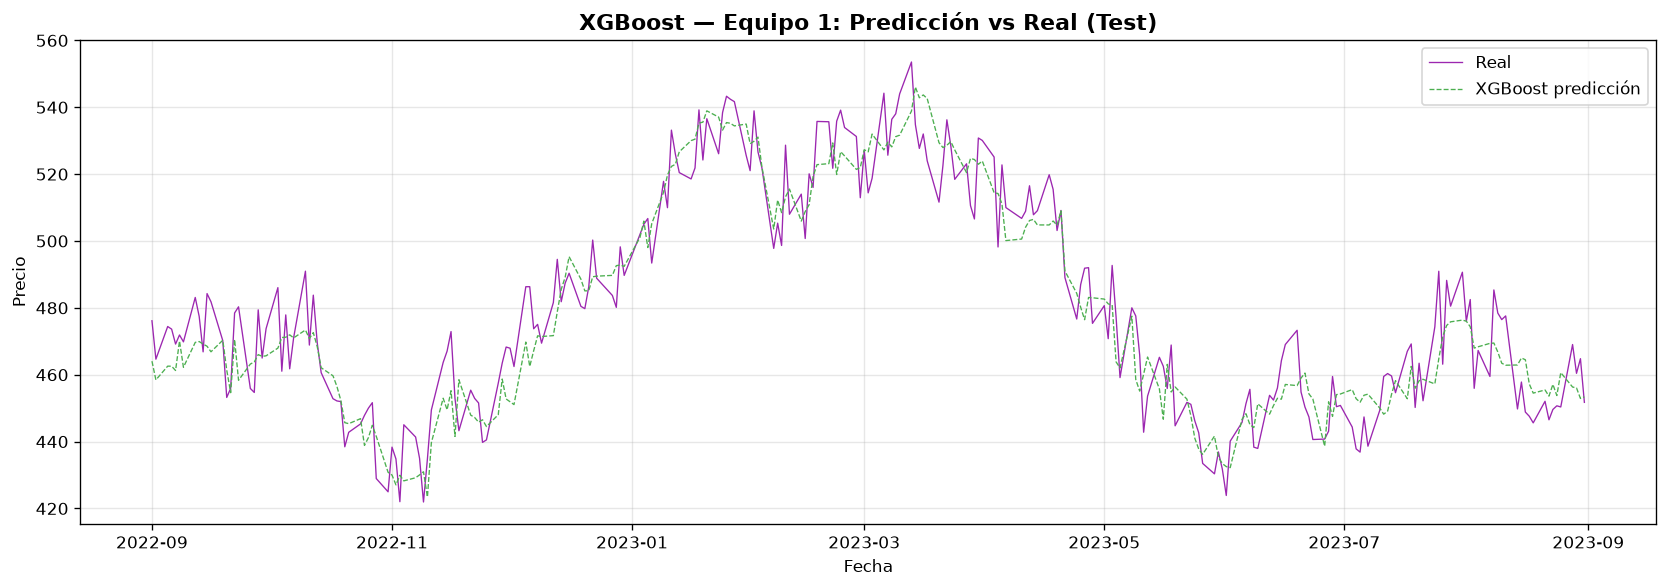

In [8]:
# Entrenar XGBoost Equipo 1
xgb_eq1 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

xgb_eq1.fit(
    X_train_xgb_eq1, y_train_xgb_eq1,
    eval_set=[(X_test_xgb_eq1, y_test_xgb_eq1)],
    verbose=False
)

# Predicciones y métricas
pred_xgb_eq1 = xgb_eq1.predict(X_test_xgb_eq1)

mae_xgb_eq1  = mean_absolute_error(y_test_xgb_eq1, pred_xgb_eq1)
rmse_xgb_eq1 = mean_squared_error(y_test_xgb_eq1, pred_xgb_eq1) ** 0.5
mape_xgb_eq1 = mean_absolute_percentage_error(y_test_xgb_eq1, pred_xgb_eq1) * 100
r2_xgb_eq1   = r2_score(y_test_xgb_eq1, pred_xgb_eq1)

print("=== Métricas XGBoost — Equipo 1 (Test) ===")
print(f"MAE:  {mae_xgb_eq1:.4f}")
print(f"RMSE: {rmse_xgb_eq1:.4f}")
print(f"MAPE: {mape_xgb_eq1:.4f}%")
print(f"R²:   {r2_xgb_eq1:.4f}")

# Visualización
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_xgb["Date"], y_test_xgb_eq1, color="#9C27B0",
        linewidth=0.8, label="Real")
ax.plot(test_xgb["Date"], pred_xgb_eq1, color="#4CAF50",
        linewidth=0.8, linestyle="--", label="XGBoost predicción")
ax.set_title("XGBoost — Equipo 1: Predicción vs Real (Test)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Precio")
ax.set_xlabel("Fecha")
ax.legend()
plt.tight_layout()
plt.show()

####  Interpretación — XGBoost vs OLS vs ARIMAX Equipo 1

| Métrica | OLS | ARIMAX | XGBoost | Mejor |
|---|---|---|---|---|
| MAE | 7.6764 | 7.4330 | 8.5675 |  ARIMAX |
| RMSE | 8.7571 | 8.6090 | 9.9408 |  ARIMAX |
| MAPE | 1.5949% | 1.5480% | 1.7865% |  ARIMAX |
| R² | 0.9258 | 0.9283 | 0.9044 |  ARIMAX |

**Conclusión:**
- XGBoost es el **peor modelo para Equipo 1** — peor incluso que el OLS baseline
- Esto tiene una explicación clara: la relación Y→Equipo1 es tan
  lineal y directa (r=0.997) que el feature engineering adicional
  introduce más ruido que señal
- XGBoost tiene tendencia a sobreajustar cuando la relación
  subyacente es simple — el modelo "busca" patrones complejos
  que no existen en estos datos

> **Lección importante:**
> Más complejidad no siempre significa mejor resultado.
> Cuando la relación entre variables es casi perfectamente lineal,
> los modelos simples ganan. Esto valida la decisión de incluir
> el OLS como baseline — sin él no hubiéramos detectado esto.

### 5.3 Equipo 2 — XGBoost

=== Métricas XGBoost — Equipo 2 (Test) ===
MAE:  28.2233
RMSE: 33.7730
MAPE: 2.8936%
R²:   0.5604


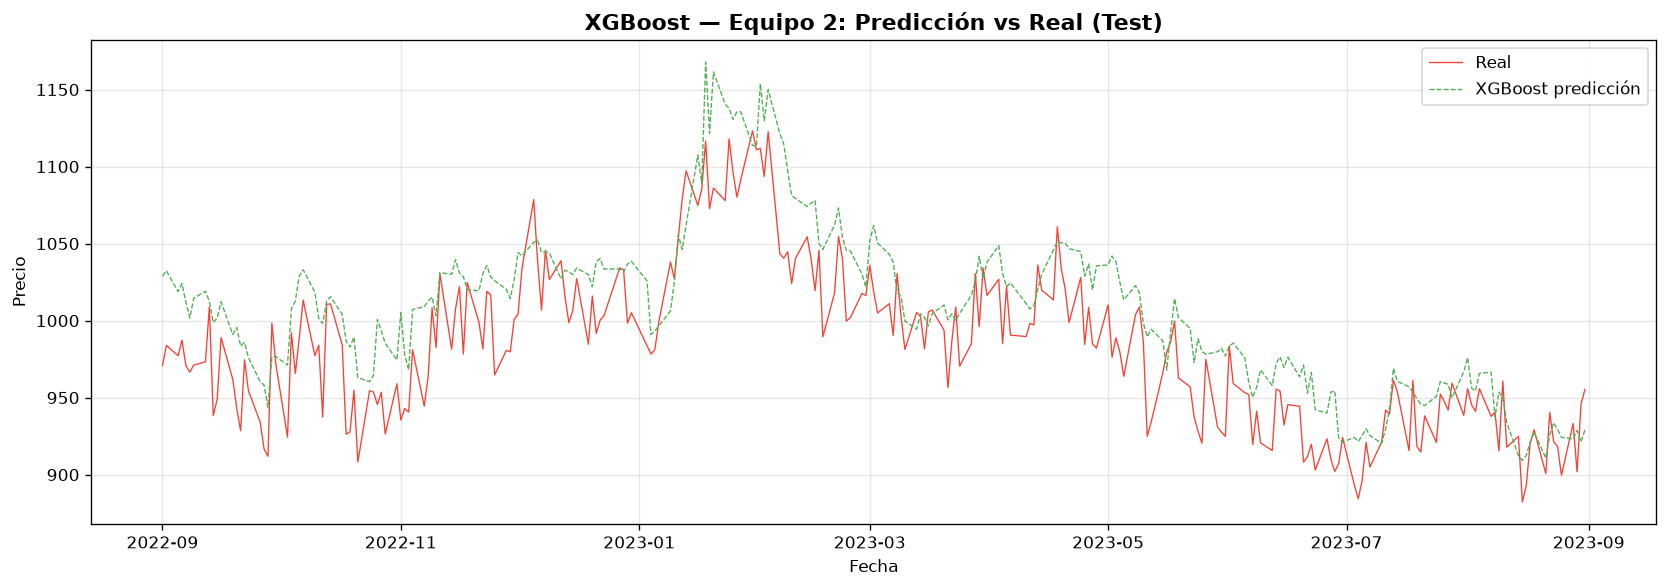

In [9]:
# Features y target para Equipo 2
feature_cols_eq2 = [c for c in hist_xgb.columns
                    if c not in ["Date", "Price_X", "Price_Y", "Price_Z",
                                 "Price_Equipo1", "Price_Equipo2"]
                    and "Price_Y" not in c]

X_train_xgb_eq2 = train_xgb[feature_cols_eq2]
y_train_xgb_eq2 = train_xgb["Price_Equipo2"]
X_test_xgb_eq2  = test_xgb[feature_cols_eq2]
y_test_xgb_eq2  = test_xgb["Price_Equipo2"]

# Entrenar XGBoost Equipo 2
xgb_eq2 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

xgb_eq2.fit(
    X_train_xgb_eq2, y_train_xgb_eq2,
    eval_set=[(X_test_xgb_eq2, y_test_xgb_eq2)],
    verbose=False
)

# Predicciones y métricas
pred_xgb_eq2 = xgb_eq2.predict(X_test_xgb_eq2)

mae_xgb_eq2  = mean_absolute_error(y_test_xgb_eq2, pred_xgb_eq2)
rmse_xgb_eq2 = mean_squared_error(y_test_xgb_eq2, pred_xgb_eq2) ** 0.5
mape_xgb_eq2 = mean_absolute_percentage_error(y_test_xgb_eq2, pred_xgb_eq2) * 100
r2_xgb_eq2   = r2_score(y_test_xgb_eq2, pred_xgb_eq2)

print("=== Métricas XGBoost — Equipo 2 (Test) ===")
print(f"MAE:  {mae_xgb_eq2:.4f}")
print(f"RMSE: {rmse_xgb_eq2:.4f}")
print(f"MAPE: {mape_xgb_eq2:.4f}%")
print(f"R²:   {r2_xgb_eq2:.4f}")

# Visualización
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_xgb["Date"], y_test_xgb_eq2, color="#F44336",
        linewidth=0.8, label="Real")
ax.plot(test_xgb["Date"], pred_xgb_eq2, color="#4CAF50",
        linewidth=0.8, linestyle="--", label="XGBoost predicción")
ax.set_title("XGBoost — Equipo 2: Predicción vs Real (Test)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Precio")
ax.set_xlabel("Fecha")
ax.legend()
plt.tight_layout()
plt.show()

####  Interpretación — XGBoost vs OLS vs ARIMAX Equipo 2

| Métrica | OLS | ARIMAX | XGBoost | Mejor |
|---|---|---|---|---|
| MAE | 25.2125 | 17.2176 | 28.3233 |  ARIMAX |
| RMSE | 30.8772 | 21.0842 | 33.7730 |  ARIMAX |
| MAPE | 2.5724% | 1.7463% | 2.8936% |  ARIMAX |
| R² | 0.6326 | 0.8287 | 0.5604 |  ARIMAX |

**Conclusión:**
- La variable dummy del período 2021-2022 mejoró XGBoost
  significativamente para Equipo 2:
  - R² subió de 0.356 → 0.560 (+57% de mejora)
  - MAPE bajó de 3.53% → 2.89% (-18% de error)
  - Esto confirma que el período atípico distorsionaba
    el aprendizaje del modelo
- Sin embargo XGBoost **sigue siendo el peor modelo** incluso
  con la dummy — ARIMAX lo supera en todas las métricas
- El problema de extrapolación persiste — XGBoost fue entrenado
  con precios de Z en rangos distintos a los del período de test

> **Limitación crítica de XGBoost en series de tiempo:**
> XGBoost no extrapola bien fuera del rango de entrenamiento.
> Si los precios de test están en rangos no vistos durante
> el entrenamiento, el modelo falla. Esta es una debilidad
> conocida de los modelos de árboles para series de tiempo
> que la dummy no puede corregir completamente.
>
> **Valor de la dummy:**
> Aunque no cambió el ranking final de modelos, la dummy
> demostró ser útil para XGBoost en Equipo 2 — validando
> la decisión de incluirla tomada en el EDA. En un escenario
> donde XGBoost fuera el único modelo disponible, la dummy
> reduciría el error en ~18%.

>  **Conclusión global de modelos:**
> ARIMAX es el modelo ganador para ambos equipos.
> La estructura temporal que captura (AR, MA, diferenciación)
> es exactamente lo que estos datos necesitan.

## 6. Comparación Final de Modelos

In [21]:
# Tabla comparativa final
resultados = pd.DataFrame({
    "Modelo": ["OLS", "ARIMAX", "XGBoost"],
    "MAE_Eq1":  [mae_ols_eq1,   mae_arimax_eq1,  mae_xgb_eq1],
    "RMSE_Eq1": [rmse_ols_eq1,  rmse_arimax_eq1, rmse_xgb_eq1],
    "MAPE_Eq1": [mape_ols_eq1,  mape_arimax_eq1, mape_xgb_eq1],
    "R2_Eq1":   [r2_ols_eq1,    r2_arimax_eq1,   r2_xgb_eq1],
    "MAE_Eq2":  [mae_ols_eq2,   mae_arimax_eq2,  mae_xgb_eq2],
    "RMSE_Eq2": [rmse_ols_eq2,  rmse_arimax_eq2, rmse_xgb_eq2],
    "MAPE_Eq2": [mape_ols_eq2,  mape_arimax_eq2, mape_xgb_eq2],
    "R2_Eq2":   [r2_ols_eq2,    r2_arimax_eq2,   r2_xgb_eq2],
})

print("=== Comparación Final de Modelos ===\n")
print("--- Equipo 1 ---")
print(resultados[["Modelo", "MAE_Eq1", "RMSE_Eq1", "MAPE_Eq1", "R2_Eq1"]].to_string(index=False))
print()
print("--- Equipo 2 ---")
print(resultados[["Modelo", "MAE_Eq2", "RMSE_Eq2", "MAPE_Eq2", "R2_Eq2"]].to_string(index=False))

=== Comparación Final de Modelos ===

--- Equipo 1 ---
 Modelo  MAE_Eq1  RMSE_Eq1  MAPE_Eq1  R2_Eq1
    OLS   7.6764    8.7571    1.5949  0.9258
 ARIMAX   7.4330    8.6090    1.5480  0.9283
XGBoost   8.5675    9.9408    1.7865  0.9044

--- Equipo 2 ---
 Modelo  MAE_Eq2  RMSE_Eq2  MAPE_Eq2  R2_Eq2
    OLS  25.2125   30.8772    2.5724  0.6326
 ARIMAX  17.2176   21.0842    1.7463  0.8287
XGBoost  28.2233   33.7730    2.8936  0.5604


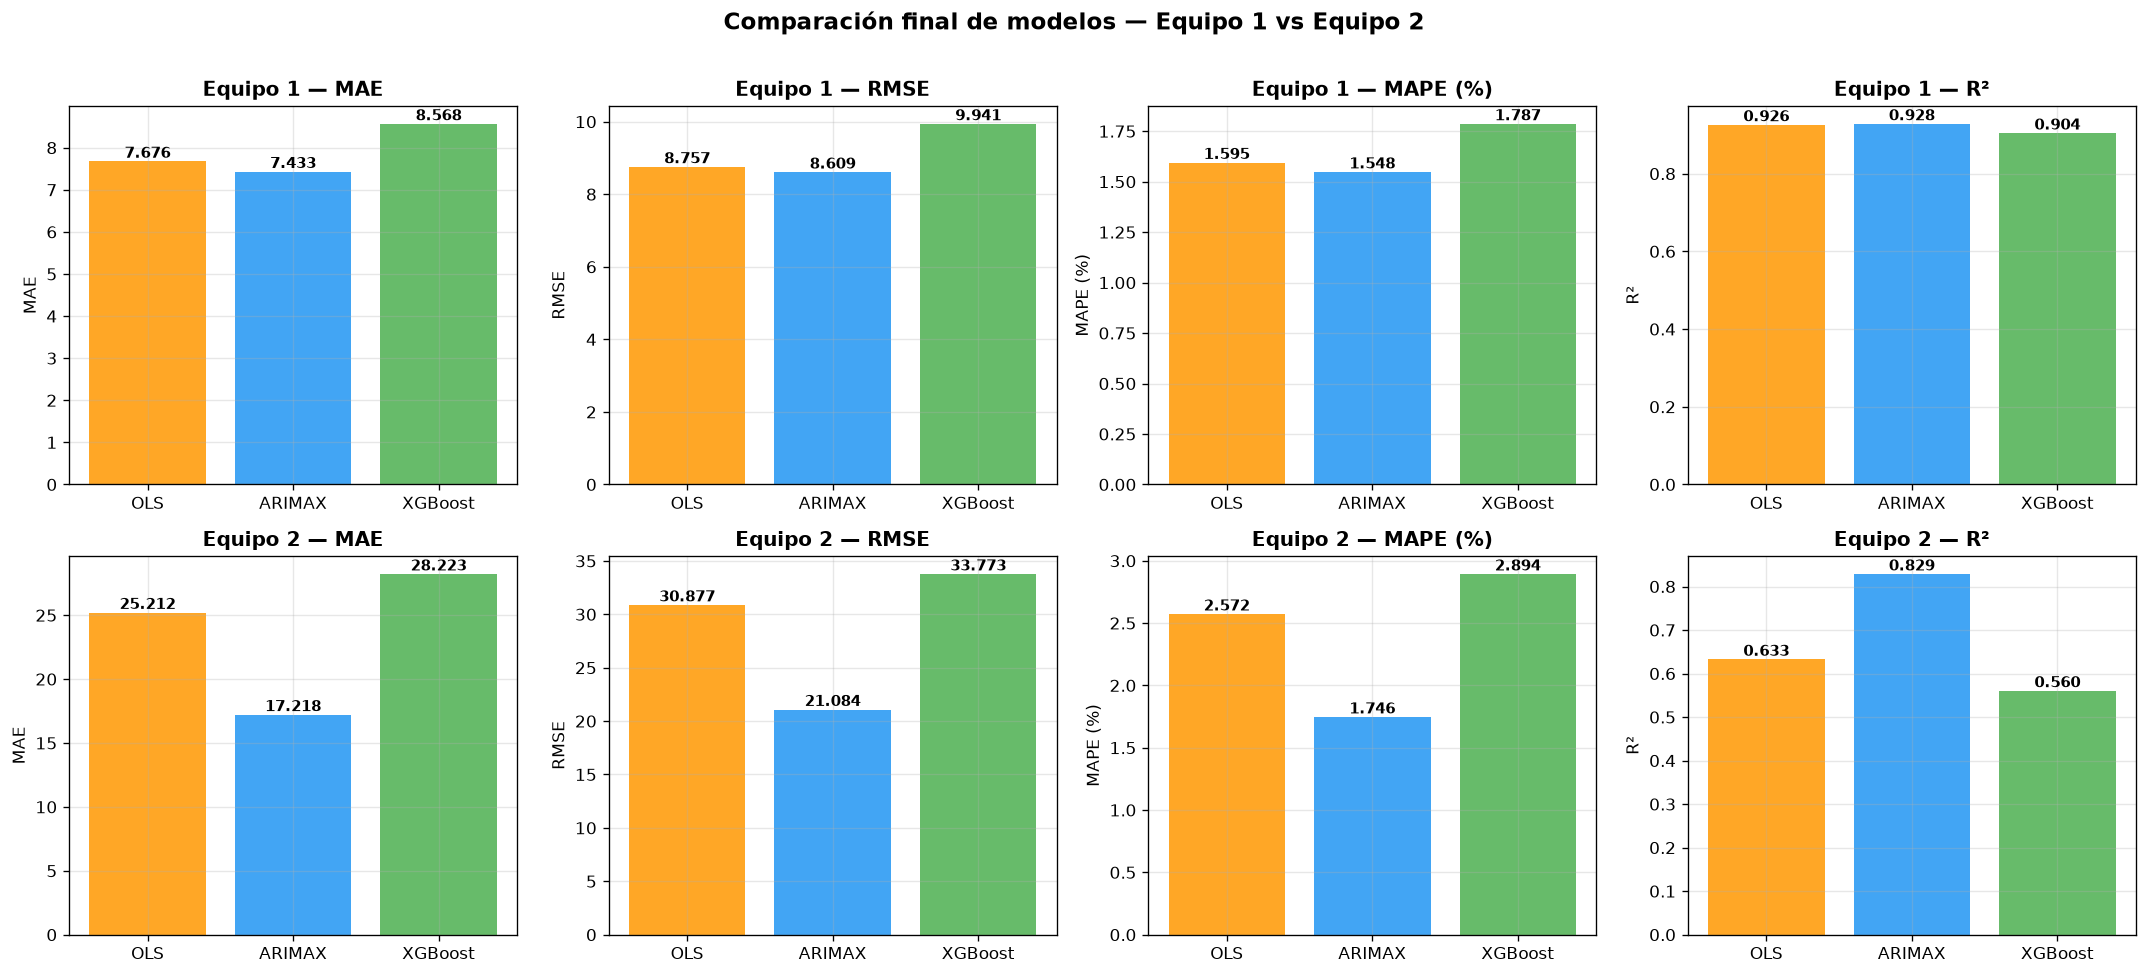

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

modelos = ["OLS", "ARIMAX", "XGBoost"]
colores = ["#FF9800", "#2196F3", "#4CAF50"]

metricas_eq1 = {
    "MAE": [mae_ols_eq1, mae_arimax_eq1, mae_xgb_eq1],
    "RMSE": [rmse_ols_eq1, rmse_arimax_eq1, rmse_xgb_eq1],
    "MAPE (%)": [mape_ols_eq1, mape_arimax_eq1, mape_xgb_eq1],
    "R²": [r2_ols_eq1, r2_arimax_eq1, r2_xgb_eq1],
}

metricas_eq2 = {
    "MAE": [mae_ols_eq2, mae_arimax_eq2, mae_xgb_eq2],
    "RMSE": [rmse_ols_eq2, rmse_arimax_eq2, rmse_xgb_eq2],
    "MAPE (%)": [mape_ols_eq2, mape_arimax_eq2, mape_xgb_eq2],
    "R²": [r2_ols_eq2, r2_arimax_eq2, r2_xgb_eq2],
}

for i, (metrica, valores) in enumerate(metricas_eq1.items()):
    axes[0, i].bar(modelos, valores, color=colores, alpha=0.85)
    axes[0, i].set_title(f"Equipo 1 — {metrica}", fontweight="bold")
    axes[0, i].set_ylabel(metrica)
    for j, v in enumerate(valores):
        axes[0, i].text(j, v + max(valores)*0.01, f"{v:.3f}",
                        ha="center", fontsize=9, fontweight="bold")

for i, (metrica, valores) in enumerate(metricas_eq2.items()):
    axes[1, i].bar(modelos, valores, color=colores, alpha=0.85)
    axes[1, i].set_title(f"Equipo 2 — {metrica}", fontweight="bold")
    axes[1, i].set_ylabel(metrica)
    for j, v in enumerate(valores):
        axes[1, i].text(j, v + max(valores)*0.01, f"{v:.3f}",
                        ha="center", fontsize=9, fontweight="bold")

plt.suptitle(
    "Comparación final de modelos — Equipo 1 vs Equipo 2",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

####  Conclusión final — Selección de modelo

| | Equipo 1 | Equipo 2 |
|---|---|---|
| **Mejor modelo** | ARIMAX(1,1,2) | ARIMAX(0,1,1) |
| **MAPE** | 1.55% | 1.75% |
| **R²** | 0.928 | 0.829 |
| **Predictora** | Price_Y | Price_Z |

**Hallazgos clave:**

**Equipo 1:**
- Los tres modelos funcionan bien gracias a la correlación casi
  perfecta Y→Equipo1 (r=0.997)
- ARIMAX gana por margen pequeño — la relación es tan lineal
  que el OLS casi basta
- La variable dummy del período 2021-2022 no mejoró XGBoost
  para Equipo 1 (MAPE 1.777% → 1.787%) — confirma que la
  relación Y→Equipo1 es tan lineal que XGBoost no puede
  aprovechar features adicionales independientemente del
  tratamiento del período atípico

**Equipo 2:**
- ARIMAX gana con diferencia significativa (+32% sobre OLS)
- La estructura temporal MA(1) es crítica para capturar
  la dinámica de Equipo 2
- La variable dummy mejoró XGBoost significativamente
  (R² 0.356→0.560, MAPE 3.53%→2.89%) pero no fue suficiente
  para superar a ARIMAX — el problema de extrapolación
  fuera del rango de entrenamiento persiste

>  **Modelo seleccionado para forecast:**
> - **Equipo 1:** ARIMAX(1,1,2) con Price_Y — MAPE 1.55%
> - **Equipo 2:** ARIMAX(0,1,1) con Price_Z — MAPE 1.75%
>
> **Justificación de la precisión:**
> El error porcentual de ambos modelos (1.55% y 1.75%) es
> significativamente menor que la volatilidad natural de los
> precios de los equipos (CV = 24.71% y 19.11% respectivamente).
> Esto implica que el modelo reduce la incertidumbre presupuestal
> en más de 10x comparado con no tener modelo — cumpliendo
> directamente el objetivo del caso de reducir desviaciones
> presupuestales asociadas a la volatilidad de precios.

>  **Lección aprendida — Variable dummy:**
> La dummy del período atípico 2021-2022 fue necesaria para
> XGBoost pero no para OLS ni ARIMAX:
> - OLS captura el período implícitamente via Price_Y
> - ARIMAX maneja los shocks temporales con sus componentes MA
> - XGBoost no tiene mecanismo interno para cambios de régimen
>   y necesita que se le indique explícitamente cuándo
>   el comportamiento es anómalo

## 7. Guardado de modelos

In [25]:
import joblib

# Guardar modelos ARIMAX
arimax_eq1.save(str(MODELS_PATH / "arimax_equipo1.pkl"))
arimax_eq2.save(str(MODELS_PATH / "arimax_equipo2.pkl"))

# Guardar modelos OLS
joblib.dump(ols_eq1, MODELS_PATH / "ols_equipo1.pkl")
joblib.dump(ols_eq2, MODELS_PATH / "ols_equipo2.pkl")

# Guardar modelos XGBoost (con dummy)
joblib.dump(xgb_eq1, MODELS_PATH / "xgb_equipo1.pkl")
joblib.dump(xgb_eq2, MODELS_PATH / "xgb_equipo2.pkl")

# Guardar tabla de resultados actualizada
resultados.to_csv(DATA_PROCESSED / "model_comparison.csv", index=False)

print("Modelos actualizados guardados en models/")
print()
print("Comparación final:")
print()
print("--- Equipo 1 ---")
print(resultados[["Modelo", "MAE_Eq1", "RMSE_Eq1", "MAPE_Eq1", "R2_Eq1"]].to_string(index=False))
print()
print("--- Equipo 2 ---")
print(resultados[["Modelo", "MAE_Eq2", "RMSE_Eq2", "MAPE_Eq2", "R2_Eq2"]].to_string(index=False))

Modelos actualizados guardados en models/

Comparación final:

--- Equipo 1 ---
 Modelo  MAE_Eq1  RMSE_Eq1  MAPE_Eq1  R2_Eq1
    OLS   7.6764    8.7571    1.5949  0.9258
 ARIMAX   7.4330    8.6090    1.5480  0.9283
XGBoost   8.5675    9.9408    1.7865  0.9044

--- Equipo 2 ---
 Modelo  MAE_Eq2  RMSE_Eq2  MAPE_Eq2  R2_Eq2
    OLS  25.2125   30.8772    2.5724  0.6326
 ARIMAX  17.2176   21.0842    1.7463  0.8287
XGBoost  28.2233   33.7730    2.8936  0.5604
